In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator


df = pd.read_csv('../data/processed/dataset_final.csv')
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
df['timestamp_paris'] = pd.to_datetime(df['timestamp_paris'], utc=True).dt.tz_convert('Europe/Paris')
df = df.sort_values("timestamp_paris").set_index("timestamp_paris")

y = df["consommation_mw"].astype(float).asfreq("h")

# Stationarité

Une série est faiblement stationnaire si son espérance et sa variance sont constantes dans le temps, et si sa covariance entre deux instants dépend uniquement de leur écart temporel.

Or, la consommation électrique présente une tendance non-linéaire et la présence de saisonnalités déterministes liées à l’heure de la journée, au jour de la semaine et à la période de l’année. Cette structure saisonnière est également mise en évidence par l’analyse des ACF et PACF. Son niveau moyen et sa variabilité dépendent donc du moment considéré. La série ne semble ainsi pas faiblement stationnaire.

KPSS test : l'hypothèse nulle est la stationnarité autour d'une constante.

In [2]:
def tests_stationnarite(serie):
    resultat_kpss = kpss(
        serie,
        regression="c",
        nlags="auto"
    )

    print(f"KPSS — p-valeur : {resultat_kpss[1]:.5g}")

    if resultat_kpss[1] < 0.05:
        print("- KPSS : l'hypothèse de stationnarité est rejetée.")
    else:
        print("- KPSS : l'hypothèse de stationnarité n'est pas rejetée.")


tests_stationnarite(y)

KPSS — p-valeur : 0.01
- KPSS : l'hypothèse de stationnarité est rejetée.


C:\Users\LeStolz\AppData\Local\Temp\ipykernel_14716\347640924.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  resultat_kpss = kpss(
C:\Users\LeStolz\AppData\Local\Temp\ipykernel_14716\347640924.py:2: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultat_kpss = kpss(


La série reste non stationnaire.

## STL

C:\Users\LeStolz\AppData\Local\Temp\ipykernel_14716\3186086694.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  else resultat.seasonal.index.to_period("W")


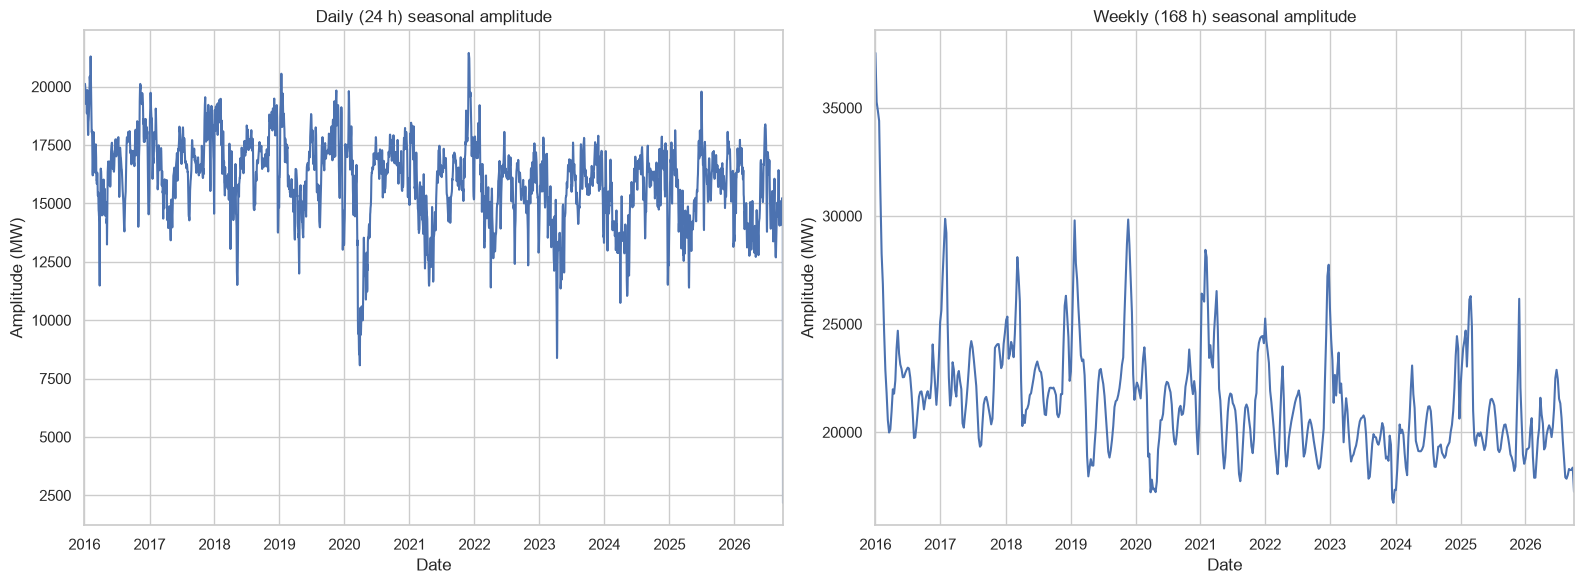

In [6]:
periods = {
    24: "Daily (24 h)",
    168: "Weekly (168 h)",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (period, label) in zip(axes, periods.items()):
    resultat = STL(y, period=period, robust=True).fit()

    # Calculate peak-to-peak amplitude over each corresponding cycle
    amplitude = resultat.seasonal.groupby(
        resultat.seasonal.index.floor("D")
        if period == 24
        else resultat.seasonal.index.to_period("W")
        if period == 168
        else resultat.seasonal.index.to_period("Y")
    ).agg(lambda x: x.max() - x.min())

    amplitude.plot(ax=ax)
    ax.set_title(f"{label} seasonal amplitude")
    ax.set_ylabel("Amplitude (MW)")
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

L'exploration et STL confirme quelquepart que l'amplitude est assez constante pour une approche additive.

## Differentiation

L'ACF a beaucoup de persistence et saisonnalité dans l'exploration, donc, on éssaie de la supprimer avec differentiation simple.

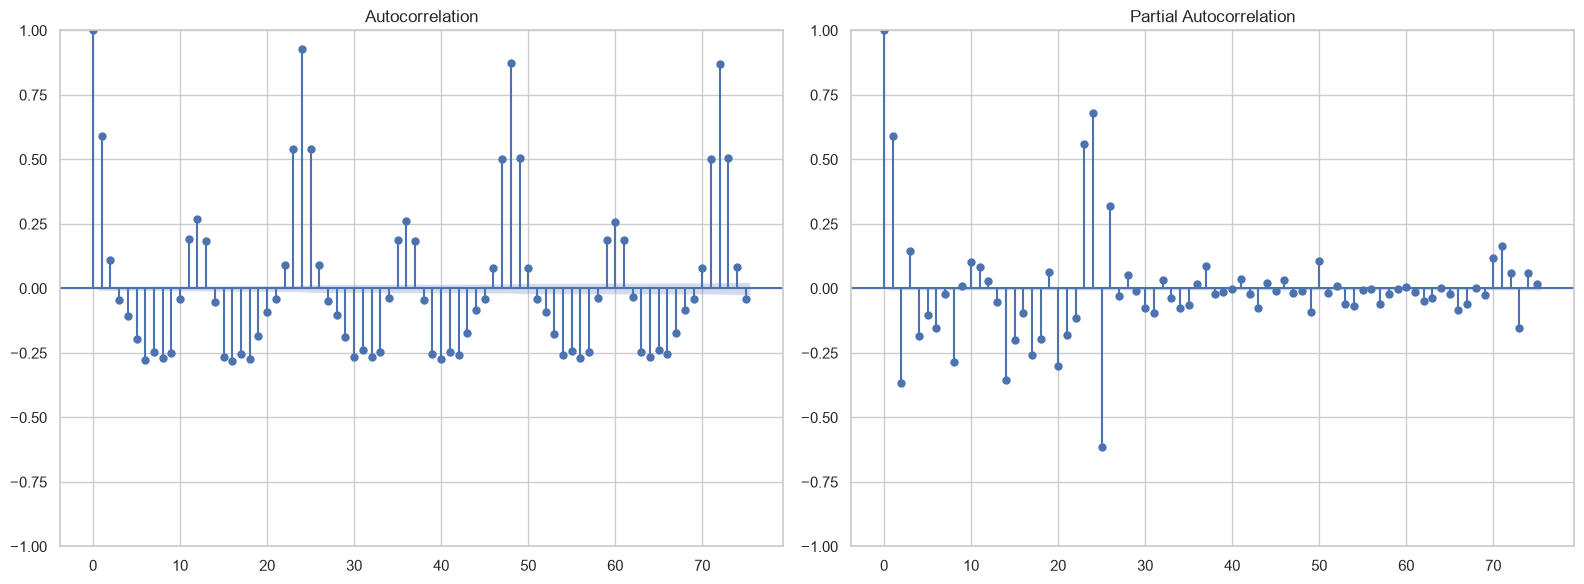

In [4]:
y_diff = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(y_diff.dropna(), lags=75, ax=axes[0])
plot_pacf(y_diff.dropna(), lags=75, ax=axes[1], method="ywm")

plt.tight_layout()
plt.show()

Il reste encore de saisonnalité, donc on éssaie la différentiation simple + saisonnière de 24 pas.

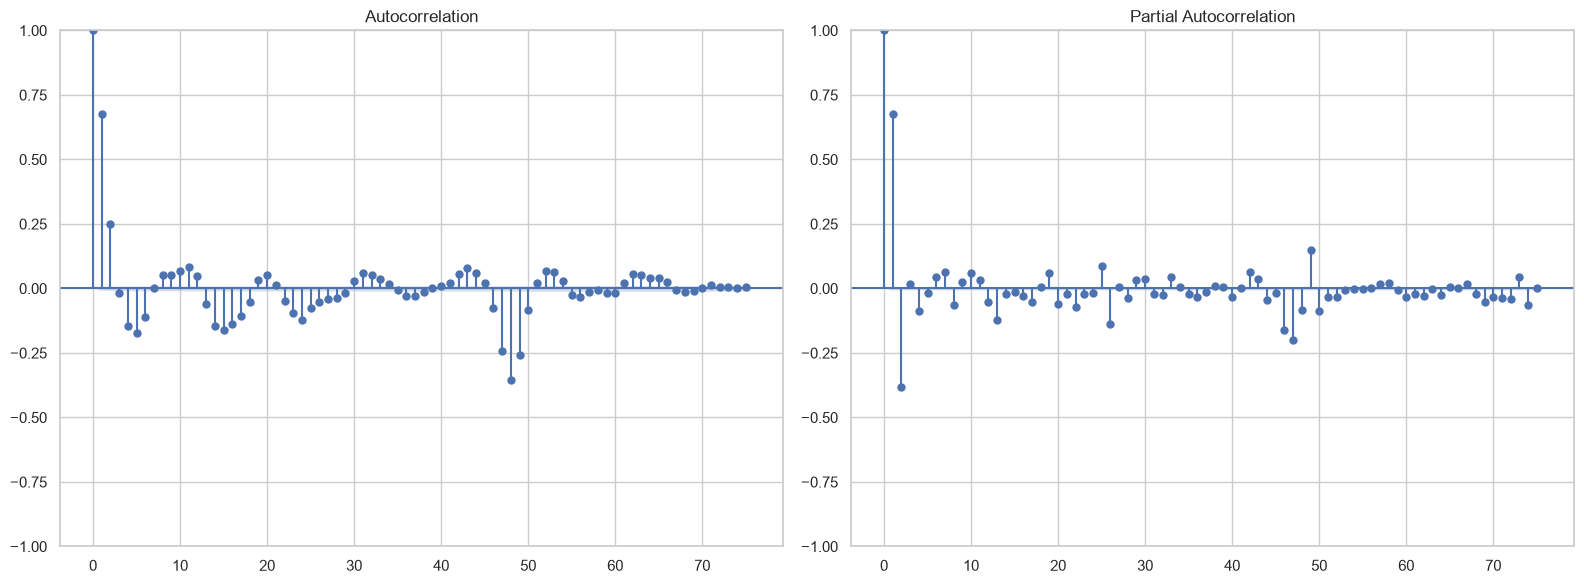

In [5]:
y_diff = y.diff().diff(periods=24).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(y_diff.dropna(), lags=75, ax=axes[0])
plot_pacf(y_diff.dropna(), lags=75, ax=axes[1], method="ywm")

plt.tight_layout()
plt.show()

Il y a encore des saisonnalités sur ACF mais on accepte.

## Synthèse

- STL — Amplitude saisonnière : l’amplitude de la composante saisonnière semble globalement stable au cours du temps. Cela suggère une série additive et pas besoin de transformation.
- ACF/PACF — Forte persistance => Tester des termes autorégressifs et la différenciation.
- Non-stationnaire et ACF/PACF — Pics à 24, 168 et environ 8 760 retards => présence de saisonnalités journalière, hebdomadaire et annuelle stable. Il faut représenter explicitement dans les modèles avec des termes Fourier, les variables calendaires et météorologiques pour les hebdomadaire et annuelle, pour journalière on utilise, c'est déjà modelisé par SARIMAX.
- Moyenne mobile et STL — Tendance non linéaire => Tester une différenciation.
- La stabilité, en terme d'écart et niveau, observée depuis 2023 pourrait constituer une base d’apprentissage pertinente. Et comme SARIMAX ne nécessite pas beaucoup de données, on peut éssayer d'entrainer sur les 2 périodes.

Donc :
- s = 24.
- p = {0, 1, 2} (PACF coupure).
- q = {0, 1, 2} (ACF coupure).
- P = {0, 1} (PACF saisonnière).
- d = {0, 1} (Pour éliminer la persistence).
- D = {0, 1} (Pour éliminer la saisonnarité).
- Q = {0, 1, 2} (ACF pas coupure saisonnière => Tester).